In [ ]:
import cv2
import skimage as skm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

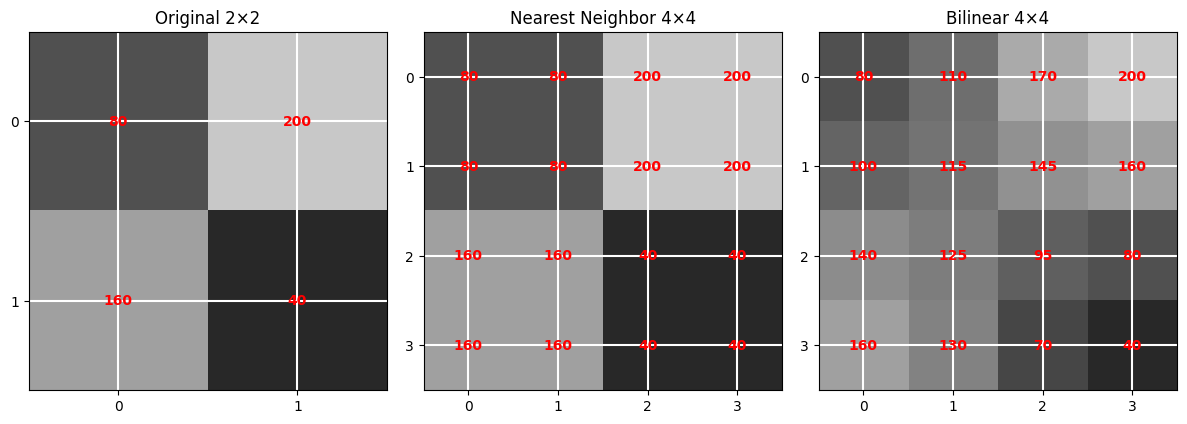

In [ ]:
src = np.array([[80, 200], [160, 40]], dtype=np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

methods = [
    ("Original 2×2",         src,                                                   None),
    ("Nearest Neighbor 4×4", cv2.resize(src, (4,4), interpolation=cv2.INTER_NEAREST), cv2.INTER_NEAREST),
    ("Bilinear 4×4",         cv2.resize(src, (4,4), interpolation=cv2.INTER_LINEAR),  cv2.INTER_LINEAR),
]

for ax, (title, img, _) in zip(axes, methods):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            ax.text(x, y, str(img[y, x]), ha='center', va='center',
                    fontsize=10, color='red', fontweight='bold')
    ax.set_title(title)
    ax.set_xticks(range(img.shape[1]))
    ax.set_yticks(range(img.shape[0]))
    ax.grid(True, color='white', linewidth=1.5)

plt.tight_layout()
plt.show()

time needed 0.0000
time needed 0.0001
time needed 0.0000


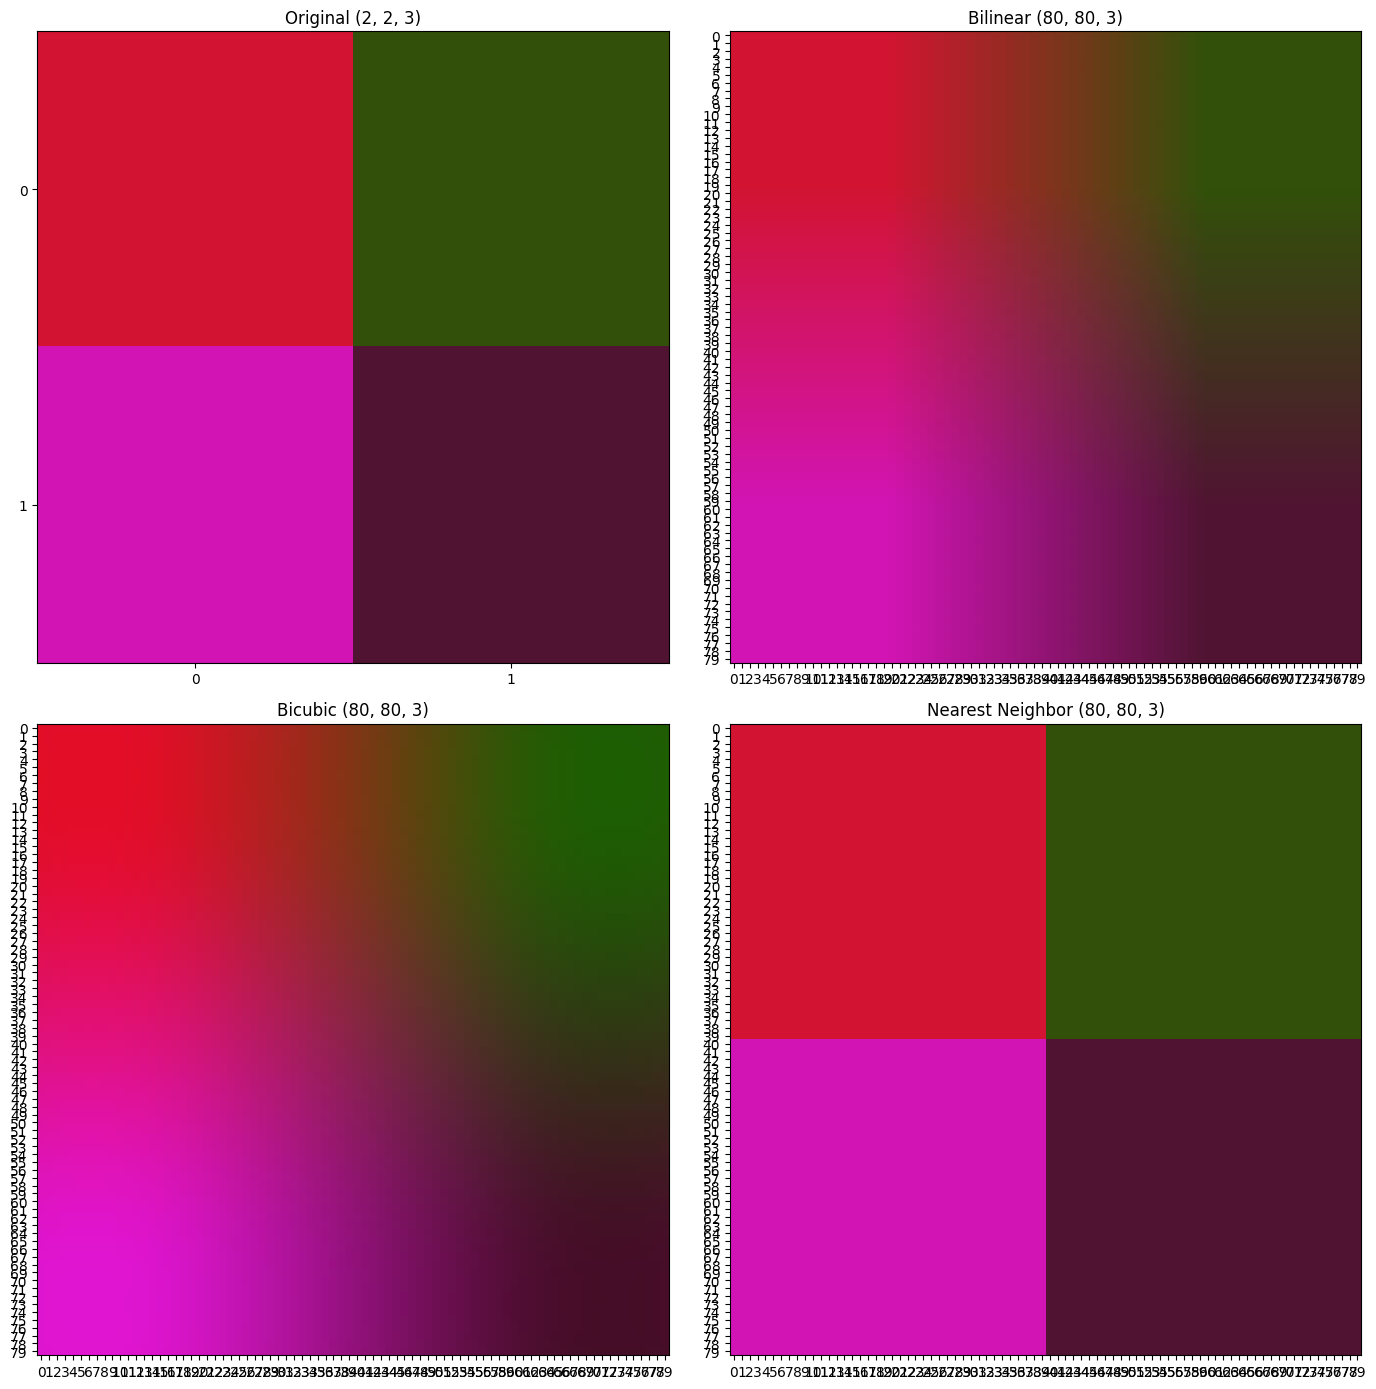

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time as tm

# Image awal
_2x2_img = np.array([
    [[210, 20,  50], [50,  80, 10]],
    [[210, 20, 180], [80,  20, 50]]
], dtype=np.uint8)

# Daftar metode interpolasi
methods = [
    ("Original", None),
    ("Bilinear", cv2.INTER_LINEAR),
    ("Bicubic", cv2.INTER_CUBIC),
    ("Nearest Neighbor", cv2.INTER_NEAREST)]

# Menentukan dimensi baru
newDimention = (80,80)

# Time processing

# Membuat layout untuk pemetaan gambar
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten() # Agar bisa multiple row

for ax, (title, interpolationMethod) in zip(axes, methods):

    if interpolationMethod == None:
        img = _2x2_img.copy()
    else:
        beg = tm.time()
        img = cv2.resize(_2x2_img, newDimention, interpolation=interpolationMethod)
        print(f"time needed {(tm.time()-beg):.4f}")

    ax.imshow(img)                          # RGB — no cmap needed
    # for y in range(img.shape[0]):
    #     for x in range(img.shape[1]):
    #         r, g, b = img[y, x]
    #         lum = 0.299*r + 0.587*g + 0.114*b
    #         color = 'white' if lum < 128 else 'black'
    #         ax.text(x, y, f"R{r}\nG{g}\nB{b}",
    #                 ha='right', va='bottom',
    #                 fontsize=7, color=color, fontweight='bold')
    ax.set_title(f"{title} {img.shape}")
    ax.set_xticks(range(img.shape[1]))
    ax.set_yticks(range(img.shape[0]))
    # ax.grid(True, color='white', linewidth=.5)

plt.tight_layout()
plt.show()

In [ ]:
# 